# Inverse problem with CFD using DeepONET Surrogate

Torch using device: cpu
JAX devices: [CpuDevice(id=0)]


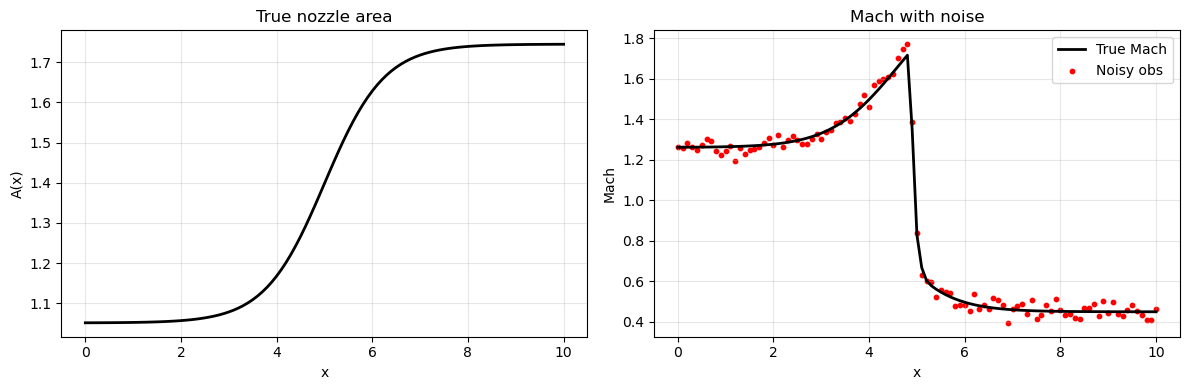

In [ ]:
# ===============================================================
# Imports + CPU-only setup + JAX CFD solver
# ===============================================================

from functools import partial
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  

import jax
import jax.numpy as jnp
from jax import lax

import numpy as onp
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from numpyro.infer.initialization import init_to_value

import torch
device_torch = torch.device("cpu")
print("Torch using device:", device_torch)

jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())


# ------------------ Forward solver (JAX CFD) ------------------
def DeltaCal_jnp(x):
    dx = jnp.zeros_like(x)
    dx = dx.at[:-1].set(x[1:] - x[:-1])
    dx = dx.at[-1].set(dx[-2])
    return dx

def EnergyCal_jnp(rho, u, P, gamma):
    return P / (gamma - 1.0) + 0.5 * rho * u**2

def ConservCal_jnp(rho, u, E, A):
    Q0 = rho * A
    Q1 = rho * u * A
    Q2 = E   * A
    return jnp.stack([Q0, Q1, Q2], axis=0)

def PrimCal_jnp(Q, A):
    rho = Q[0] / A
    u   = Q[1] / Q[0]
    E   = Q[2] / A
    return rho, u, E

def PressureCal_jnp(rho, u, E, gamma):
    return (gamma - 1.0) * (E - 0.5 * rho * u**2)

def FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma):
    N = u.size
    zeros = jnp.zeros(N)
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    M = u / c

    mask_sub     = jnp.abs(M) < 1.0
    mask_le_neg1 = M <= -1.0
    mask_gt_pos1 = M >  1.0

    PP  = jnp.where(mask_sub, 0.5*(1+M)*P, 0.0)
    PN  = jnp.where(mask_sub, 0.5*(1-M)*P, 0.0)
    PuP = jnp.where(mask_sub, 0.5*(u+c)*P, 0.0)
    PuN = jnp.where(mask_sub, 0.5*(u-c)*P, 0.0)

    PP  = jnp.where(mask_gt_pos1, P,  PP)
    PuP = jnp.where(mask_gt_pos1, u*P, PuP)
    PN  = jnp.where(mask_le_neg1, P,  PN)
    PuN = jnp.where(mask_le_neg1, u*P, PuN)

    Fp0 = jnp.where(u>0, rho*u*A, 0.0)
    Fp1 = jnp.where(u>0, (rho*u**2+PP)*A, PP*A)
    Fp2 = jnp.where(u>0, (u*E+PuP)*A,    PuP*A)

    Fn0 = jnp.where(u<0, rho*u*A, 0.0)
    Fn1 = jnp.where(u<0, (rho*u**2+PN)*A, PN*A)
    Fn2 = jnp.where(u<0, (u*E+PuN)*A,    PuN*A)

    FP = jnp.stack([Fp0, Fp1, Fp2], axis=0)
    FN = jnp.stack([Fn0, Fn1, Fn2], axis=0)
    H  = jnp.stack([zeros, P*dAdx, zeros], axis=0)
    return FP, FN, H

def TimeStep_jnp(dx, rho, u, P, cfl, gamma):
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    cmax = jnp.max(jnp.abs(u) + c)
    return cfl * dx[1] / cmax

@partial(jax.jit, static_argnames=("gamma",))
def apply_bc(rho, u, P, E, gamma):
    # inlet (supersonic)
    rho = rho.at[0].set(0.5008261)
    u   = u.at[0].set(1.0991840)
    P   = P.at[0].set(0.2712900)
    E   = E.at[0].set(EnergyCal_jnp(rho[0], u[0], P[0], gamma))

    # outlet (subsonic: fixed P, extrapolated rho,u)
    rho = rho.at[-1].set(2.0 * rho[-2] - rho[-3])
    u   = u.at[-1].set(2.0 * u[-2]   - u[-3])
    P   = P.at[-1].set(0.5156000)
    E   = E.at[-1].set(EnergyCal_jnp(rho[-1], u[-1], P[-1], gamma))
    return rho, u, P, E

def upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt):
    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)
    rho, u, P, E = apply_bc(rho, u, P, E, gamma)
    Q = ConservCal_jnp(rho, u, E, A)
    FP, FN, H = FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma)

    def update_col(i, Q):
        Qi = Q[:, i]
        dF = (FP[:, i] - FP[:, i-1] + FN[:, i+1] - FN[:, i])
        Qi_new = Qi - (dt / dx[i]) * dF + dt * H[:, i]
        return Q.at[:, i].set(Qi_new)

    N = A.size
    Q_new = lax.fori_loop(1, N-1, update_col, Q)
    return Q_new

@partial(jax.jit, static_argnames=("n_steps","gamma","cfl"))
def forward_only_jax(x, A, n_steps=5000, gamma=1.4, cfl=0.9):
    x = jnp.asarray(x); A = jnp.asarray(A)
    N = A.size

    dAdx0  = (A[1]  - A[0])  / (x[1]  - x[0])
    dAdxN1 = (A[-1] - A[-2]) / (x[-1] - x[-2])
    dAdx_mid = (A[2:] - A[:-2]) / (x[2:] - x[:-2])
    dAdx = jnp.concatenate([dAdx0[None], dAdx_mid, dAdxN1[None]])

    dx = DeltaCal_jnp(x)

    rho = jnp.ones(N) * 0.7511383
    u   = jnp.ones(N) * 0.4416178
    P   = jnp.ones(N) * 0.2156000
    E   = EnergyCal_jnp(rho, u, P, gamma)
    Q   = ConservCal_jnp(rho, u, E, A)

    def body_fun(step, Q):
        rho0, u0, E0 = PrimCal_jnp(Q, A)
        P0 = PressureCal_jnp(rho0, u0, E0, gamma)
        dt = TimeStep_jnp(dx, rho0, u0, P0, cfl, gamma)
        return upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt)

    Q = lax.fori_loop(0, n_steps, body_fun, Q)

    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    M = u / c
    return rho, u, P, M


# ===============================================================
# Observation data generation (truth + noisy Mach)
# ===============================================================

def A_true_fn(x):
    return 1.398 + 0.347 * jnp.tanh(0.8 * x - 4.0)

# Grid / solver params
N       = 101
x       = jnp.linspace(0.0, 10.0, N, dtype=jnp.float32)
L       = float(x[-1])
gamma   = 1.4
cfl     = 0.9
n_steps = 5000

# Truth area + forward truth Mach
A_true  = A_true_fn(x)
A0_val  = float(A_true[0])
A10_val = float(A_true[-1])

rho_true, u_true, P_true, M_true = forward_only_jax(x, A_true, n_steps=n_steps, gamma=gamma, cfl=cfl)

# Add noise to Mach observations
rng = onp.random.default_rng(0)
noise_sigma = 0.03
M_obs = onp.array(M_true) + noise_sigma * rng.standard_normal((N,))

# Use all points 
obs_idx = onp.arange(N, dtype=onp.int32)

# Quick check plot
x_np = onp.asarray(x)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_np, onp.asarray(A_true), "k-", lw=2)
plt.xlabel("x"); plt.ylabel("A(x)"); plt.title("True nozzle area"); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(x_np, onp.asarray(M_true), "k-", lw=2, label="True Mach")
plt.scatter(x_np, M_obs, s=10, c="r", label="Noisy obs")
plt.xlabel("x"); plt.ylabel("Mach"); plt.title("Mach with noise")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()



Inverse B-spline Greville points: [ 0.         0.6333333  2.0600002  3.646667   4.76       5.24
  6.3533335  7.94       9.366667  10.       ]
Baseline controls c_base_inv: [1.0512371 1.0512522 1.0518303 1.0771701 1.3008037 1.4951963 1.7188299
 1.7441697 1.7447476 1.7447629]


sample: 100%|██████████| 6000/6000 [00:03<00:00, 1756.39it/s, 15 steps of size 9.52e-02. acc. prob=0.96]


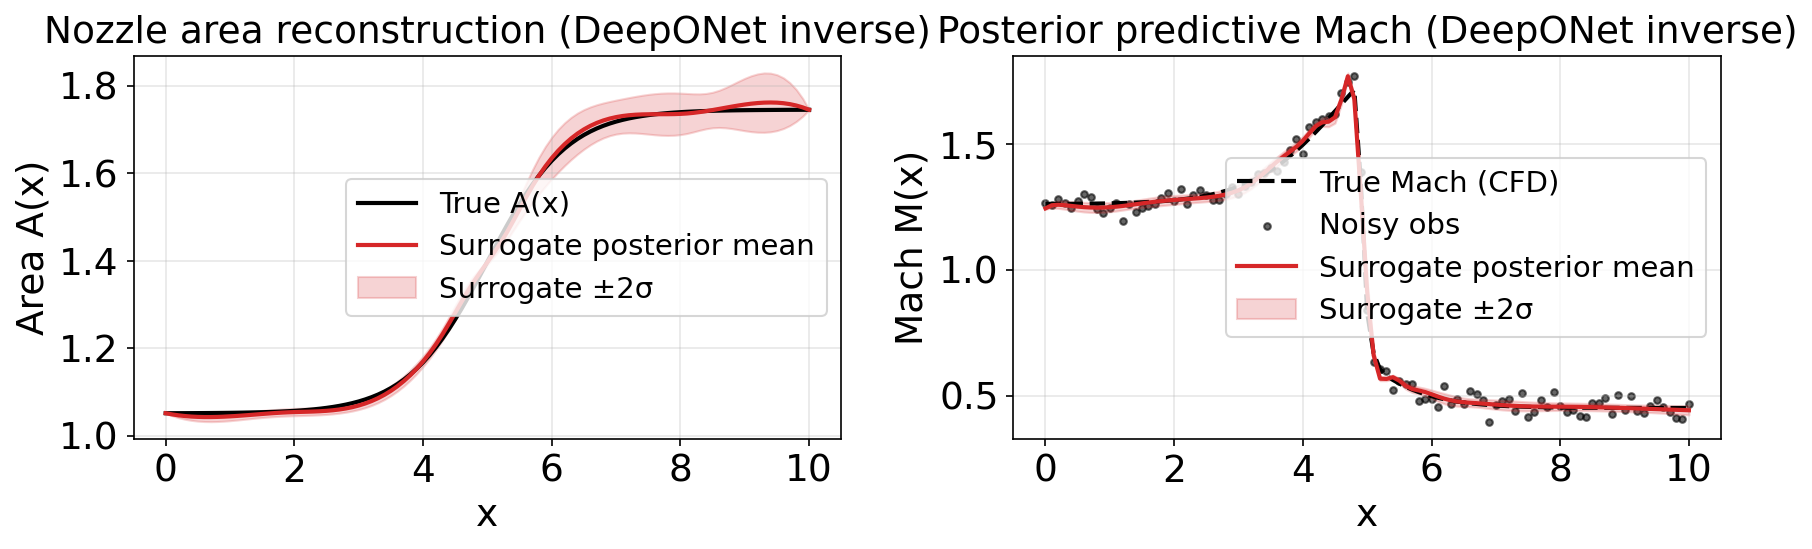

In [ ]:
# ===============================================================
# Bayesian inverse using trained DeepONet surrogate
#     - Unknowns: B-spline nozzle controls
#     - Forward: DeepONet surrogate A(x; c) -> M(x)
#     - Data: noisy Mach from CFD "true" nozzle
# ===============================================================
# -----------------------------
# B-spline setup for inverse
# -----------------------------
K_inv    = K_bs     # number of control points (10)
deg_inv  = deg_bs   # cubic
x_c_inv  = x_c      # throat center
width_inv= 1.2
prior_span = 0.3   # bounds for interior control deltas

x0 = float(x[0]); x1 = float(x[-1])
knots_inv = clustered_knots_x(K_inv, deg_inv, x0, x1, center=x_c_inv, width=width_inv)
B_full_inv, knots_x_inv = bspline_basis_matrix_x(x, K=K_inv, degree=deg_inv,
                                                 knots=knots_inv, x0=x0, x1=x1)

# Greville abscissae to define smooth baseline controls
grev_inv = jnp.array([(knots_x_inv[i+1:i+1+deg_inv]).mean()
                      for i in range(K_inv)], dtype=jnp.float32)
s_inv = jnp.tanh(1.2 * (grev_inv - x_c_inv))
s_inv = 0.5 * (1.0 + s_inv)
c_base_inv = A0_val + (AL_val - A0_val) * s_inv   # baseline control vector (K_inv,)

print("Inverse B-spline Greville points:", grev_inv)
print("Baseline controls c_base_inv:", c_base_inv)

# -----------------------------
# Forward map via DeepONet from controls
# -----------------------------
def forward_deeponet_from_ctrls(params_dn, c, x_grid):
    """
    c: (K_inv,) B-spline control vector
    x_grid: (N,)
    returns: A_full(x), M_pred(x)
    """
    A_full = B_full_inv @ c           # (N,)
    M_pred = deeponet_apply_single_jit(params_dn, A_full, x_grid)
    return A_full, M_pred

# # Quick sanity check on forward_deeponet_from_ctrls
# with jax.disable_jit():
#     c_true = jnp.linalg.lstsq(B_full_inv, A_true, rcond=None)[0]  # rough fit
#     A_check, M_check = forward_deeponet_from_ctrls(params_dn, c_true, x)
#     plt.figure(figsize=(6,4))
#     plt.plot(onp.array(x), onp.array(M_true), 'k-', label='CFD true')
#     plt.plot(onp.array(x), onp.array(M_check), 'r--', label='DeepONet(c_true)')
#     plt.legend(); plt.grid(alpha=0.3); plt.title("Sanity check: surrogate vs CFD"); plt.tight_layout()
#     plt.show()

# -----------------------------
# NumPyro model
# -----------------------------
def model_bspline_deeponet_inverse(
    x_full, M_obs_full, obs_idx,
    params_dn,
    A0, AL,
    prior_span=0.25,
    sigma_prior=0.03
):
    """
    Bayesian inverse model using DeepONet surrogate.
      - Unknown: interior B-spline control deltas (K_inv - 2)
      - Controls: c = [A0, c_base[1:-1] + delta, AL]
      - Forward: DeepONet(M | A(x; c))
      - Likelihood: Gaussian on Mach data
    """
    K = K_inv

    # Uniform prior on interior control deltas
    lo = -prior_span * jnp.ones((K-2,), dtype=jnp.float32)
    hi =  prior_span * jnp.ones((K-2,), dtype=jnp.float32)
    delta = numpyro.sample("delta", dist.Uniform(lo, hi))  # (K-2,)

    # Build full control vector
    c_interior = c_base_inv[1:-1] + delta
    c = jnp.concatenate([
        jnp.array([A0]),
        c_interior,
        jnp.array([AL])
    ])
    numpyro.deterministic("c", c)

    # Area via B-spline
    A_full, M_pred_full = forward_deeponet_from_ctrls(params_dn, c, x_full)
    A_full = jnp.clip(A_full, a_min=1e-3, a_max=None)
    numpyro.deterministic("A_full", A_full)

    # Extract predictions at observed points
    M_pred = M_pred_full[obs_idx]

    # Observation noise
    sigma = numpyro.sample("sigma", dist.HalfNormal(sigma_prior))

    with numpyro.plate("data", M_pred.shape[0]):
        numpyro.sample("M_obs", dist.Normal(M_pred, sigma), obs=M_obs_full)

# -----------------------------
# Run NUTS / MCMC
# -----------------------------
x_full_jnp  = x
obs_idx_jnp = jnp.array(obs_idx, dtype=jnp.int32)
M_obs_jnp   = jnp.array(M_obs, dtype=jnp.float32)

init_params_inv = {
    "delta": jnp.zeros((K_inv-2,), dtype=jnp.float32),
    "sigma": jnp.array(noise_sigma, dtype=jnp.float32),
}

nuts_kernel = NUTS(
    model_bspline_deeponet_inverse,
    init_strategy=init_to_value(values=init_params_inv),
    target_accept_prob=0.9,
    max_tree_depth=6,
)

mcmc_inv = MCMC(
    nuts_kernel,
    num_warmup=1000,
    num_samples=5000,
    num_chains=1,
    progress_bar=True,
)

rng_key_inv = jax.random.PRNGKey(123)
mcmc_inv.run(
    rng_key_inv,
    x_full=x_full_jnp,
    M_obs_full=M_obs_jnp,
    obs_idx=obs_idx_jnp,
    params_dn=params_dn,
    A0=A0_val,
    AL=AL_val,
    prior_span=prior_span,
    sigma_prior=0.05,
)
samples_inv = mcmc_inv.get_samples()

# -----------------------------
# Posterior reconstruction & plots
# -----------------------------
c_samps = samples_inv["c"]           # (S, K_inv)
S = c_samps.shape[0]

# Posterior A(x)
A_samps = c_samps @ B_full_inv.T     # (S, N)
A_mu = jnp.mean(A_samps, axis=0)
A_sd = jnp.std(A_samps, axis=0)

# Posterior predictive Mach via DeepONet
S_pp = min(120, S)
idx_pp = onp.linspace(0, S-1, S_pp, dtype=int)

M_samps = []
for s_idx in idx_pp:
    c_draw = c_samps[s_idx]
    _, M_pred = forward_deeponet_from_ctrls(params_dn, c_draw, x_full_jnp)
    M_samps.append(M_pred)
M_samps = jnp.stack(M_samps, axis=0)
M_mu = jnp.mean(M_samps, axis=0)
M_sd = jnp.std(M_samps, axis=0)

x_np      = onp.array(x_full_jnp)
A_true_np = onp.array(A_true)
M_true_np = onp.array(M_true)

fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Area reconstruction
axs[0].plot(x_np, A_true_np, 'k-', lw=2, label="True A(x)")
axs[0].plot(x_np, onp.array(A_mu), 'C3-', lw=2, label="Surrogate posterior mean")
axs[0].fill_between(
    x_np,
    onp.array(A_mu - 2*A_sd),
    onp.array(A_mu + 2*A_sd),
    color='C3', alpha=0.2, label="Surrogate ±2σ"
)
axs[0].set_xlabel('x'); axs[0].set_ylabel('Area A(x)')
axs[0].set_title('Nozzle area reconstruction (DeepONet inverse)')
axs[0].grid(alpha=0.3); axs[0].legend()

# Mach reconstruction
axs[1].plot(x_np, M_true_np, 'k--', lw=2, label="True Mach (CFD)")
axs[1].scatter(x_np, M_obs, s=10, c='k', alpha=0.6, label="Noisy obs")
axs[1].plot(x_np, onp.array(M_mu), 'C3-', lw=2, label="Surrogate posterior mean")
axs[1].fill_between(
    x_np,
    onp.array(M_mu - 2*M_sd),
    onp.array(M_mu + 2*M_sd),
    color='C3', alpha=0.2, label="Surrogate ±2σ"
)
axs[1].set_xlabel('x'); axs[1].set_ylabel('Mach M(x)')
axs[1].set_title('Posterior predictive Mach (DeepONet inverse)')
axs[1].grid(alpha=0.3); axs[1].legend()

plt.tight_layout()
plt.show()


# Observation Density Effects for 5, 10, 20, 40, 80 and 100

In [ ]:
# ===============================================================
# Load dataset + Load trained DeepONet + B-spline utilities
# ===============================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # CPU-only

import numpy as onp
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.tree_util as tree_util

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from numpyro.infer.initialization import init_to_value


# -----------------------
# Load dataset (truth)
# -----------------------
DATA_FILE = "deeponet_nozzle_dataset.npz"
data = onp.load(DATA_FILE, allow_pickle=True)

x      = jnp.array(data["x"], dtype=jnp.float32)
A_true = jnp.array(data["A_true"], dtype=jnp.float32)
M_true = jnp.array(data["M_true"], dtype=jnp.float32)

N = int(x.shape[0])
x0 = float(x[0]); x1 = float(x[-1])

# boundary areas inferred from true nozzle 
A0_val = float(A_true[0])
AL_val = float(A_true[-1])

print("Loaded:", DATA_FILE)
print("Grid N =", N, "A0 =", A0_val, "AL =", AL_val)


# -----------------------
# Load training meta (normalization)
# -----------------------
META_FILE = "deeponet_training_meta.npz"
meta = onp.load(META_FILE, allow_pickle=True)

mu_A  = jnp.array(meta["mu_A"])
std_A = jnp.array(meta["std_A"])
x_min = float(meta["x_min"])
x_max = float(meta["x_max"])

def normalize_x(x_grid):
    return 2.0 * ((x_grid - x_min) / (x_max - x_min) - 0.5)

print("Loaded:", META_FILE)


# -----------------------
# DeepONet architecture 
# -----------------------
def init_layer(key, in_dim, out_dim):
    w_key, _ = jax.random.split(key)
    W = jax.random.normal(w_key, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim)
    b = jnp.zeros((out_dim,))
    return (W, b)

def init_mlp(sizes, key):
    params = []
    keys = jax.random.split(key, len(sizes)-1)
    for (m, n), k in zip(zip(sizes[:-1], sizes[1:]), keys):
        params.append(init_layer(k, m, n))
    return params

def mlp_apply(params, x):
    for (W, b) in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W_last, b_last = params[-1]
    return x @ W_last + b_last

def init_deeponet(key, n_grid, p=64,
                  hidden_branch=(128, 128),
                  hidden_trunk=(64, 64)):
    kb, kt, _ = jax.random.split(key, 3)
    branch_sizes = (n_grid,) + hidden_branch + (p,)
    trunk_sizes  = (1,)      + hidden_trunk  + (p,)
    branch_params = init_mlp(branch_sizes, kb)
    trunk_params  = init_mlp(trunk_sizes,  kt)
    bias = jnp.array(0.0)
    return {"branch": branch_params, "trunk": trunk_params, "bias": bias}

def deeponet_apply_single(params, A_sample, x_grid):
    # normalize inputs (must match training)
    A_n = (A_sample - mu_A) / std_A
    x_n = normalize_x(x_grid)[:, None]  # (N,1)

    # branch / trunk
    b_feat = mlp_apply(params["branch"], A_n[None, :])[0]  # (p,)
    t_feat = mlp_apply(params["trunk"], x_n)               # (N,p)

    # dot-product output
    M_pred = jnp.sum(t_feat * b_feat[None, :], axis=1) + params["bias"]
    return M_pred

deeponet_apply_single_jit = jax.jit(deeponet_apply_single)

def deeponet_apply_batch(params, A_batch, x_grid):
    return jax.vmap(lambda A: deeponet_apply_single_jit(params, A, x_grid))(A_batch)


# -----------------------
# Load saved model params 
# -----------------------
PARAMS_FILE = "deeponet_params_best.npz"

key_tmp = jax.random.PRNGKey(0)
params_template = init_deeponet(key_tmp, n_grid=N, p=64)
_, treedef = tree_util.tree_flatten(params_template)

loaded = onp.load(PARAMS_FILE)
flat_loaded = [jnp.array(loaded[f"arr_{i}"]) for i in range(len(loaded.files))]
params_dn = tree_util.tree_unflatten(treedef, flat_loaded)

print("Loaded:", PARAMS_FILE)


# -----------------------
# B-spline utilities 
# -----------------------
def clustered_knots_x(K, degree, x0, x1, center, width=1.2):
    n_int = K - degree - 1
    left  = max(x0 + 1e-6, center - width)
    right = min(x1 - 1e-6, center + width)
    n_center = max(2, int(0.7 * n_int))
    n_outer = n_int - n_center

    def seg(a, b, n):
        if n <= 0:
            return jnp.array([], dtype=jnp.float32)
        return jnp.linspace(a, b, n + 2, dtype=jnp.float32)[1:-1]

    center_knots = seg(left, right, n_center)
    left_knots   = seg(x0, left, n_outer // 2)
    right_knots  = seg(right, x1, n_outer - (n_outer // 2))

    interior = jnp.sort(jnp.concatenate([left_knots, center_knots, right_knots], axis=0))
    knots = jnp.concatenate([
        jnp.full((degree+1,), x0), interior, jnp.full((degree+1,), x1)
    ])
    return knots

def bspline_basis_matrix_x(xv, K=10, degree=3, knots=None, x0=0.0, x1=10.0):
    m = knots.size - 1
    xclip = jnp.clip(xv, x0, jnp.nextafter(x1, x0))
    xcol = xclip[:, None]
    N0 = ((xcol >= knots[:-1]) & (xcol < knots[1:])).astype(jnp.float32)

    Nmat = N0
    for d in range(1, degree+1):
        i_count = m - d
        Lk, Rk = knots[:i_count], knots[d:m]
        denomL = Rk - Lk
        a = jnp.where(denomL > 0, (xcol - Lk)/denomL, 0.0)

        Lk2, Rk2 = knots[1:i_count+1], knots[d+1:m+1]
        denomR = Rk2 - Lk2
        b = jnp.where(denomR > 0, (Rk2 - xcol)/denomR, 0.0)

        Nmat = a * Nmat[:, :i_count] + b * Nmat[:, 1:i_count+1]
    return Nmat, knots


# -----------------------
# Inverse B-spline basis + baseline controls
# -----------------------
K_inv = 10
deg_inv = 3
x_c_inv = 5.0
cluster_width = 1.5

knots_inv = clustered_knots_x(K_inv, deg_inv, x0, x1, center=x_c_inv, width=cluster_width)
B_full_inv, knots_x_inv = bspline_basis_matrix_x(
    x, K=K_inv, degree=deg_inv, knots=knots_inv, x0=x0, x1=x1
)

grev_inv = jnp.array([(knots_x_inv[i+1:i+1+deg_inv]).mean()
                      for i in range(K_inv)], dtype=jnp.float32)
s_inv = 0.5 * (1.0 + jnp.tanh(1.2 * (grev_inv - x_c_inv)))
c_base_inv = A0_val + (AL_val - A0_val) * s_inv

print("Greville points:", onp.array(grev_inv))
print("Baseline controls:", onp.array(c_base_inv))


# -----------------------
# Forward: controls -> A(x) -> DeepONet -> M(x)
# -----------------------
def forward_deeponet_from_ctrls(params_dn, c, x_grid):
    A_full = B_full_inv @ c
    M_pred = deeponet_apply_single_jit(params_dn, A_full, x_grid)
    return A_full, M_pred


Loaded: deeponet_nozzle_dataset.npz
Grid N = 101 A0 = 1.0512328147888184 AL = 1.744767189025879
Loaded: deeponet_training_meta.npz
Loaded: deeponet_params_best.npz
Greville points: [ 0.         0.5833334  1.95       3.516667   4.7000003  5.3
  6.4833336  8.05       9.416667  10.       ]
Baseline controls: [1.0512371 1.0512501 1.0516918 1.0704107 1.2782912 1.517709  1.7255893
 1.7443082 1.7447499 1.7447629]


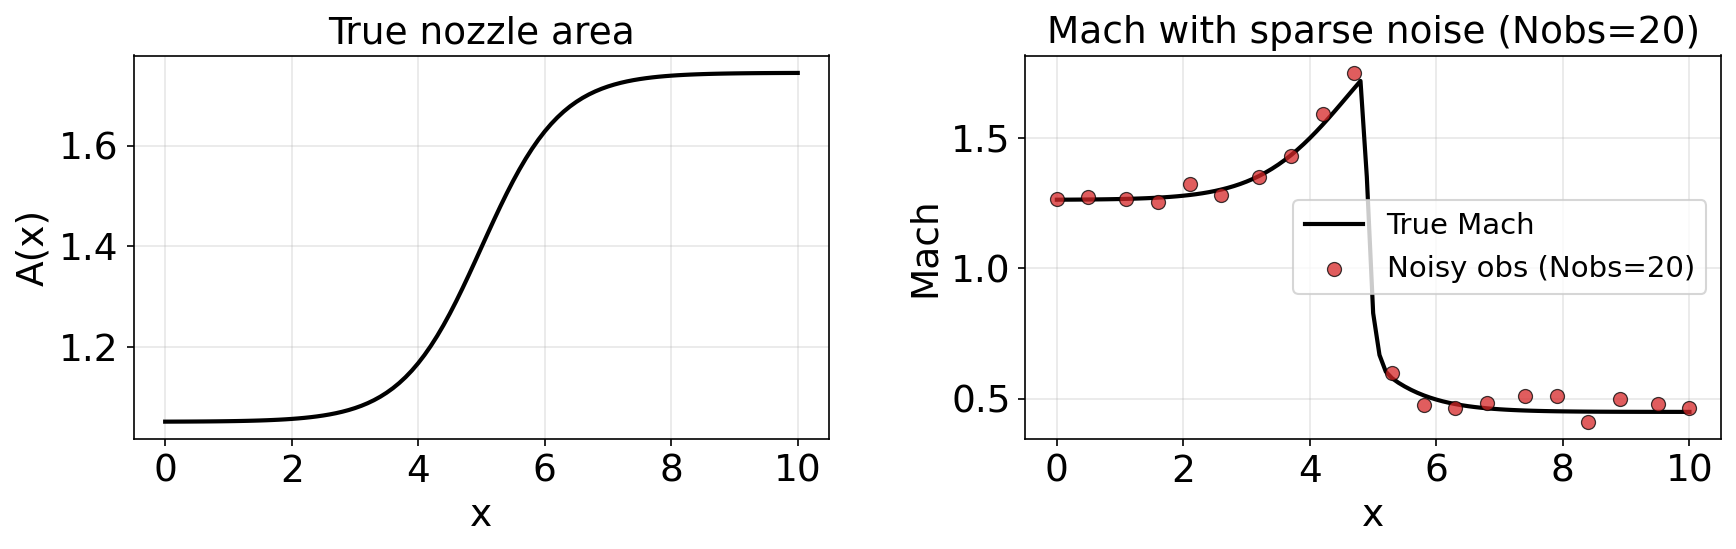

obs_idx: [  0   5  11  16  21  26  32  37  42  47  53  58  63  68  74  79  84  89
  95 100]
noise_sigma: 0.03


sample: 100%|██████████| 400/400 [00:01<00:00, 353.02it/s, 15 steps of size 1.06e-01. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  delta[0]     -0.02      0.03     -0.02     -0.07      0.02    196.02      1.00
  delta[1]      0.03      0.04      0.03     -0.03      0.09    142.10      1.00
  delta[2]     -0.05      0.04     -0.05     -0.12      0.00    109.45      1.00
  delta[3]      0.05      0.04      0.05     -0.00      0.12    124.79      1.00
  delta[4]     -0.05      0.05     -0.05     -0.12      0.02    133.47      1.00
  delta[5]      0.04      0.09      0.04     -0.09      0.21    112.42      1.00
  delta[6]     -0.10      0.10     -0.12     -0.25      0.04    146.31      1.00
  delta[7]     -0.05      0.10     -0.05     -0.22      0.10    279.76      1.00
     sigma      0.04      0.01      0.04      0.02      0.05    103.09      1.00

Number of divergences: 0


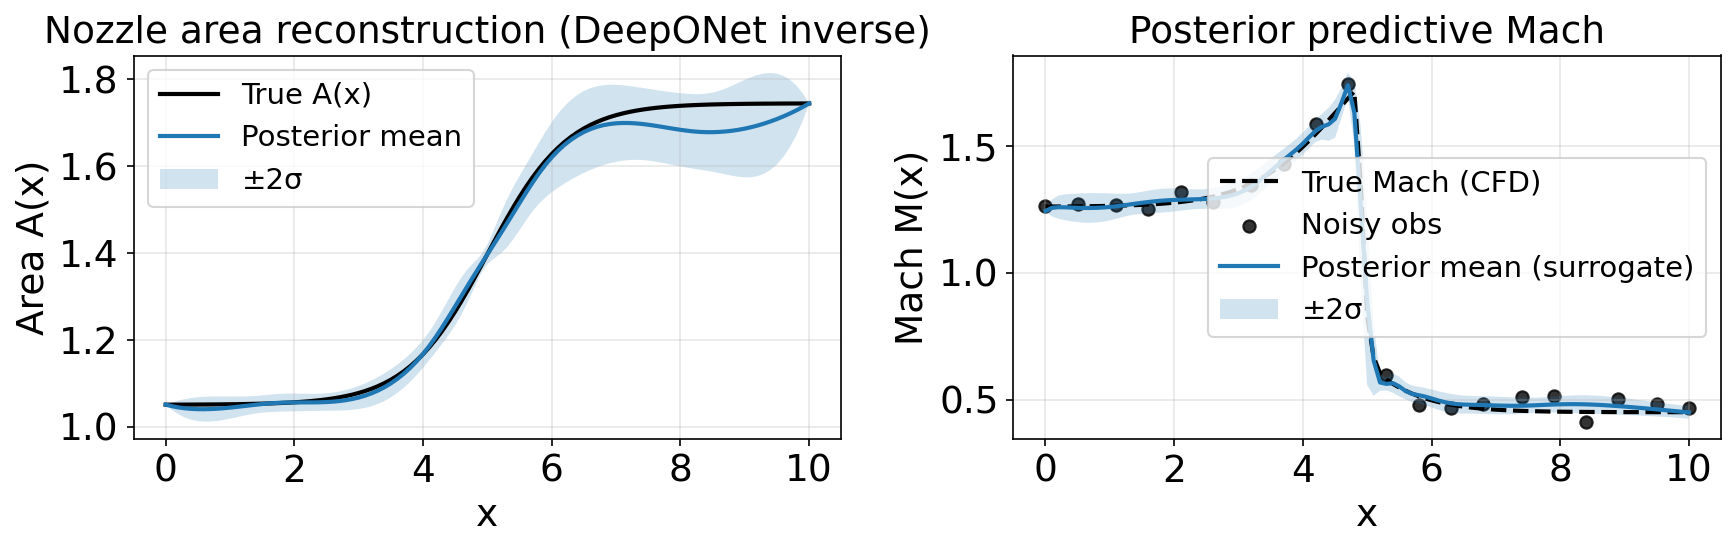

Saved -> inverse_results_DeepONet_Time_Check_20obs.npz


In [ ]:
# ===============================================================
# Bayesian inverse (NumPyro NUTS) using DeepONet surrogate
# ===============================================================

# -----------------------------
# Truth + observations on single grid 
# -----------------------------
x_full = jnp.asarray(x, dtype=jnp.float32)

rng = onp.random.default_rng(0)
noise_sigma = 0.03

# noise added on the FULL grid first
M_obs_full = onp.array(M_true) + noise_sigma * rng.standard_normal((N,))

# ---------------------------------------------------
# Use uniformly-spaced observation points
# ---------------------------------------------------
Nobs = 20
obs_idx = onp.linspace(0, N-1, Nobs).round().astype(onp.int32)
obs_idx = onp.unique(obs_idx) 

# Subsampled observations used in likelihood
x_np  = onp.asarray(x)
x_obs = x_np[obs_idx]
M_obs = M_obs_full[obs_idx]

# convert to JAX
obs_idx_jnp = jnp.array(obs_idx, dtype=jnp.int32)
M_obs_jnp   = jnp.array(M_obs, dtype=jnp.float32)

# Quick check plot (show only the sparse obs) 
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_np, onp.asarray(A_true), "k-", lw=2)
plt.xlabel("x"); plt.ylabel("A(x)"); plt.title("True nozzle area"); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(x_np, onp.asarray(M_true), "k-", lw=2, label="True Mach")
plt.scatter(
    x_obs, M_obs,
    s=45,
    facecolor="tab:red",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.75,
    label=f"Noisy obs (Nobs={len(obs_idx)})",
    zorder=3
)
plt.xlabel("x"); plt.ylabel("Mach"); plt.title(f"Mach with sparse noise (Nobs={len(obs_idx)})")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("obs_idx:", obs_idx)
print("noise_sigma:", noise_sigma)


# -----------------------------
# NumPyro model (unknown interior control deltas)
# -----------------------------
def model_bspline_deeponet_inverse(
    x_full, M_obs_full, obs_idx,
    params_dn,
    A0, AL,
    prior_span=0.25,
    sigma_prior=0.05
):
    K = K_inv

    lo = -prior_span * jnp.ones((K-2,), dtype=jnp.float32)
    hi =  prior_span * jnp.ones((K-2,), dtype=jnp.float32)
    delta = numpyro.sample("delta", dist.Uniform(lo, hi))  # (K-2,)

    c_interior = c_base_inv[1:-1] + delta
    c = jnp.concatenate([jnp.array([A0]), c_interior, jnp.array([AL])])
    numpyro.deterministic("c", c)

    A_full, M_pred_full = forward_deeponet_from_ctrls(params_dn, c, x_full)
    A_full = jnp.clip(A_full, a_min=1e-3, a_max=None)
    numpyro.deterministic("A_full", A_full)

    M_pred = M_pred_full[obs_idx]

    sigma = numpyro.sample("sigma", dist.HalfNormal(sigma_prior))
    with numpyro.plate("data", M_pred.shape[0]):
        numpyro.sample("M_obs", dist.Normal(M_pred, sigma), obs=M_obs_full)


# -----------------------------
# Run NUTS / MCMC
# -----------------------------
prior_span = 0.25
sigma_prior = 0.05

init_params_inv = {
    "delta": jnp.zeros((K_inv-2,), dtype=jnp.float32),
    "sigma": jnp.array(noise_sigma, dtype=jnp.float32),
}

nuts_kernel = NUTS(
    model_bspline_deeponet_inverse,
    init_strategy=init_to_value(values=init_params_inv),
    target_accept_prob=0.90,
    max_tree_depth=6,
)

mcmc = MCMC(
    nuts_kernel,
    num_warmup=100,
    num_samples=300,
    num_chains=1,
    progress_bar=True,
)

rng_key = jax.random.PRNGKey(123)
mcmc.run(
    rng_key,
    x_full=x_full,
    M_obs_full=M_obs_jnp,
    obs_idx=obs_idx_jnp,
    params_dn=params_dn,
    A0=A0_val,
    AL=AL_val,
    prior_span=prior_span,
    sigma_prior=sigma_prior,
)
samples = mcmc.get_samples()
mcmc.print_summary()


# -----------------------------
# 4) Posterior reconstruction
# -----------------------------
c_samps = samples["c"]                 # (S, K_inv)
S = int(c_samps.shape[0])

A_samps = c_samps @ B_full_inv.T       # (S, N)
A_mu = jnp.mean(A_samps, axis=0)
A_sd = jnp.std(A_samps, axis=0)

S_pp = min(120, S)
idx_pp = onp.linspace(0, S-1, S_pp, dtype=int)

M_samps = []
for s_idx in idx_pp:
    c_draw = c_samps[s_idx]
    _, M_pred = forward_deeponet_from_ctrls(params_dn, c_draw, x_full)
    M_samps.append(M_pred)
M_samps = jnp.stack(M_samps, axis=0)

M_mu = jnp.mean(M_samps, axis=0)
M_sd = jnp.std(M_samps, axis=0)


# -----------------------------
# 5) Plots (A and Mach recon)
# -----------------------------
x_np = onp.array(x_full)
A_true_np = onp.array(A_true)
M_true_np = onp.array(M_true)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(x_np, A_true_np, "k-", lw=2, label="True A(x)")
axs[0].plot(x_np, onp.array(A_mu), lw=2, label="Posterior mean")
axs[0].fill_between(
    x_np,
    onp.array(A_mu - 2*A_sd),
    onp.array(A_mu + 2*A_sd),
    alpha=0.2,
    label="±2σ"
)
axs[0].set_xlabel("x"); axs[0].set_ylabel("Area A(x)")
axs[0].set_title("Nozzle area reconstruction (DeepONet inverse)")
axs[0].grid(alpha=0.3); axs[0].legend()

axs[1].plot(x_np, M_true_np, "k--", lw=2, label="True Mach (CFD)")
axs[1].scatter(x_np[obs_idx], M_obs, s=35, c="k", alpha=0.8, label="Noisy obs")
axs[1].plot(x_np, onp.array(M_mu), lw=2, label="Posterior mean (surrogate)")
axs[1].fill_between(
    x_np,
    onp.array(M_mu - 2*M_sd),
    onp.array(M_mu + 2*M_sd),
    alpha=0.2,
    label="±2σ"
)
axs[1].set_xlabel("x"); axs[1].set_ylabel("Mach M(x)")
axs[1].set_title("Posterior predictive Mach")
axs[1].grid(alpha=0.3); axs[1].legend()

plt.tight_layout()
plt.show()


# -----------------------------
# Save results 
# -----------------------------
Nobs_used = int(len(obs_idx))        
OUT_FILE = f"inverse_results_DeepONet_Time_Check_{Nobs_used}obs.npz"

onp.savez(
    OUT_FILE,
    x=onp.array(x_full),
    obs_idx=onp.array(obs_idx),
    x_obs=onp.array(x_obs),
    M_obs_full=onp.array(M_obs_full),
    M_obs=onp.array(M_obs),
    noise_sigma=onp.array(noise_sigma),
    delta=onp.array(samples["delta"]),
    sigma=onp.array(samples["sigma"]),
    c=onp.array(samples["c"]),
    A_full=onp.array(samples["A_full"]),
    A_mu=onp.array(A_mu),
    A_sd=onp.array(A_sd),
    M_mu=onp.array(M_mu),
    M_sd=onp.array(M_sd),
    A_true=onp.array(A_true),
    M_true=onp.array(M_true),
    meta=onp.array([Nobs_used, prior_span, sigma_prior, 1000, 5000], dtype=onp.float32),
)

print("Saved ->", OUT_FILE)



In [16]:
import platform
import psutil
import jax
import numpyro
import sys

env_info = {
    "python_version": sys.version,
    "os": platform.platform(),
    "cpu": platform.processor(),
    "cpu_cores": psutil.cpu_count(logical=True),
    "ram_gb": round(psutil.virtual_memory().total / 1e9, 2),
    "jax_version": jax.__version__,
    "numpyro_version": numpyro.__version__,
    "jax_backend": jax.default_backend(),
    "jax_devices": [str(d) for d in jax.devices()],
}

for k, v in env_info.items():
    print(f"{k}: {v}")


python_version: 3.9.23 (main, Jun  5 2025, 13:40:20) 
[GCC 11.2.0]
os: Linux-6.14.0-37-generic-x86_64-with-glibc2.39
cpu: x86_64
cpu_cores: 32
ram_gb: 67.09
jax_version: 0.4.30
numpyro_version: 0.19.0
jax_backend: cpu
jax_devices: ['TFRT_CPU_0']


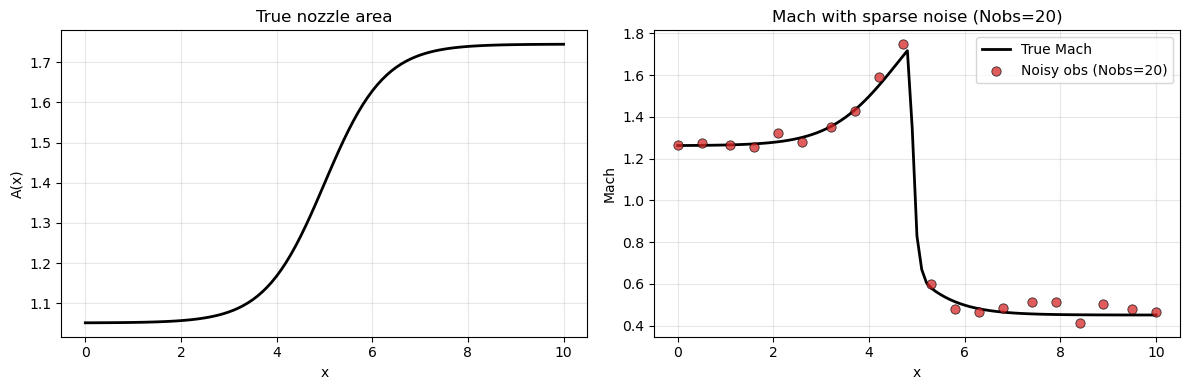

obs_idx: [  0   5  11  16  21  26  32  37  42  47  53  58  63  68  74  79  84  89
  95 100]
noise_sigma: 0.03


sample: 100%|██████████| 6000/6000 [00:46<00:00, 128.12it/s, 31 steps of size 7.49e-02. acc. prob=0.97]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  delta[0]     -0.02      0.04     -0.02     -0.08      0.02     91.73      1.01
  delta[1]      0.03      0.04      0.03     -0.03      0.09    290.72      1.00
  delta[2]     -0.05      0.04     -0.05     -0.11      0.02    388.67      1.00
  delta[3]      0.05      0.04      0.05     -0.01      0.12    771.20      1.00
  delta[4]     -0.05      0.05     -0.05     -0.14      0.02   1614.12      1.00
  delta[5]      0.05      0.10      0.05     -0.11      0.22   1419.40      1.00
  delta[6]     -0.10      0.11     -0.12     -0.25      0.05   2463.79      1.00
  delta[7]     -0.05      0.11     -0.05     -0.24      0.10   1401.41      1.00
     sigma      0.04      0.01      0.03      0.02      0.05   1593.24      1.00

Number of divergences: 3


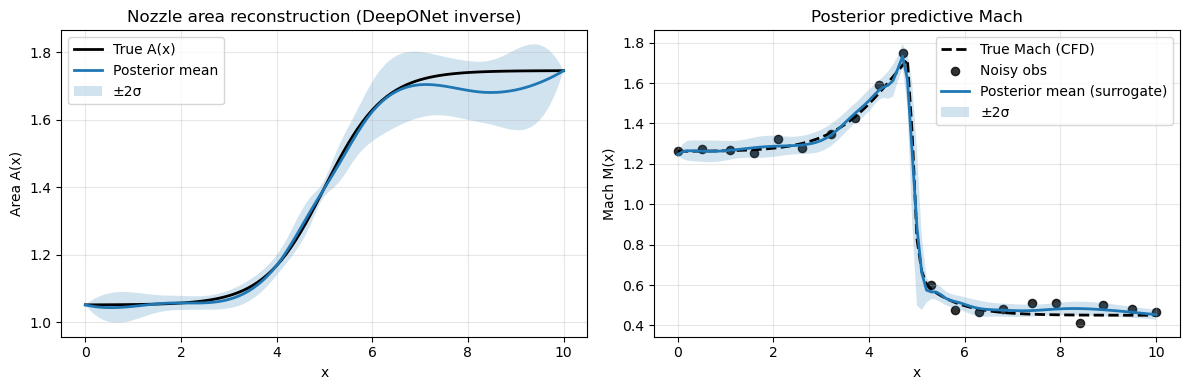

Saved -> inverse_results_DeepONet_20obs.npz


In [ ]:
# ===============================================================
# Bayesian inverse (NumPyro NUTS) using DeepONet surrogate
# ===============================================================

# -----------------------------
# 1) Truth + observations on single grid 
# -----------------------------
x_full = jnp.asarray(x, dtype=jnp.float32)

rng = onp.random.default_rng(0)
noise_sigma = 0.03

# noise added on the FULL grid first
M_obs_full = onp.array(M_true) + noise_sigma * rng.standard_normal((N,))

# ---------------------------------------------------
# Use uniformly-spaced observation points
# (set Nobs to 5, 10, 20, 40, 80 and 100 to study different observation density effects
# ---------------------------------------------------
Nobs = 20
obs_idx = onp.linspace(0, N-1, Nobs).round().astype(onp.int32)
obs_idx = onp.unique(obs_idx)  # safety

# Subsampled observations used in likelihood
x_np  = onp.asarray(x)
x_obs = x_np[obs_idx]
M_obs = M_obs_full[obs_idx]

# convert to JAX
obs_idx_jnp = jnp.array(obs_idx, dtype=jnp.int32)
M_obs_jnp   = jnp.array(M_obs, dtype=jnp.float32)

# Quick check plot (show only the sparse obs) 
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_np, onp.asarray(A_true), "k-", lw=2)
plt.xlabel("x"); plt.ylabel("A(x)"); plt.title("True nozzle area"); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(x_np, onp.asarray(M_true), "k-", lw=2, label="True Mach")
plt.scatter(
    x_obs, M_obs,
    s=45,
    facecolor="tab:red",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.75,
    label=f"Noisy obs (Nobs={len(obs_idx)})",
    zorder=3
)
plt.xlabel("x"); plt.ylabel("Mach"); plt.title(f"Mach with sparse noise (Nobs={len(obs_idx)})")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("obs_idx:", obs_idx)
print("noise_sigma:", noise_sigma)


# -----------------------------
# 2) NumPyro model (unknown interior control deltas)
# -----------------------------
def model_bspline_deeponet_inverse(
    x_full, M_obs_full, obs_idx,
    params_dn,
    A0, AL,
    prior_span=0.25,
    sigma_prior=0.05
):
    K = K_inv

    lo = -prior_span * jnp.ones((K-2,), dtype=jnp.float32)
    hi =  prior_span * jnp.ones((K-2,), dtype=jnp.float32)
    delta = numpyro.sample("delta", dist.Uniform(lo, hi))  # (K-2,)

    c_interior = c_base_inv[1:-1] + delta
    c = jnp.concatenate([jnp.array([A0]), c_interior, jnp.array([AL])])
    numpyro.deterministic("c", c)

    A_full, M_pred_full = forward_deeponet_from_ctrls(params_dn, c, x_full)
    A_full = jnp.clip(A_full, a_min=1e-3, a_max=None)
    numpyro.deterministic("A_full", A_full)

    M_pred = M_pred_full[obs_idx]

    sigma = numpyro.sample("sigma", dist.HalfNormal(sigma_prior))
    with numpyro.plate("data", M_pred.shape[0]):
        numpyro.sample("M_obs", dist.Normal(M_pred, sigma), obs=M_obs_full)


# -----------------------------
# 3) Run NUTS / MCMC
# -----------------------------
prior_span = 0.25
sigma_prior = 0.05

init_params_inv = {
    "delta": jnp.zeros((K_inv-2,), dtype=jnp.float32),
    "sigma": jnp.array(noise_sigma, dtype=jnp.float32),
}

nuts_kernel = NUTS(
    model_bspline_deeponet_inverse,
    init_strategy=init_to_value(values=init_params_inv),
    target_accept_prob=0.90,
    max_tree_depth=6,
)

mcmc = MCMC(
    nuts_kernel,
    num_warmup=1000,
    num_samples=5000,
    num_chains=1,
    progress_bar=True,
)

rng_key = jax.random.PRNGKey(123)
mcmc.run(
    rng_key,
    x_full=x_full,
    M_obs_full=M_obs_jnp,
    obs_idx=obs_idx_jnp,
    params_dn=params_dn,
    A0=A0_val,
    AL=AL_val,
    prior_span=prior_span,
    sigma_prior=sigma_prior,
)
samples = mcmc.get_samples()
mcmc.print_summary()


# -----------------------------
# 4) Posterior reconstruction
# -----------------------------
c_samps = samples["c"]                 # (S, K_inv)
S = int(c_samps.shape[0])

A_samps = c_samps @ B_full_inv.T       # (S, N)
A_mu = jnp.mean(A_samps, axis=0)
A_sd = jnp.std(A_samps, axis=0)

S_pp = min(120, S)
idx_pp = onp.linspace(0, S-1, S_pp, dtype=int)

M_samps = []
for s_idx in idx_pp:
    c_draw = c_samps[s_idx]
    _, M_pred = forward_deeponet_from_ctrls(params_dn, c_draw, x_full)
    M_samps.append(M_pred)
M_samps = jnp.stack(M_samps, axis=0)

M_mu = jnp.mean(M_samps, axis=0)
M_sd = jnp.std(M_samps, axis=0)


# -----------------------------
# 5) Plots (A and Mach recon)
# -----------------------------
x_np = onp.array(x_full)
A_true_np = onp.array(A_true)
M_true_np = onp.array(M_true)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(x_np, A_true_np, "k-", lw=2, label="True A(x)")
axs[0].plot(x_np, onp.array(A_mu), lw=2, label="Posterior mean")
axs[0].fill_between(
    x_np,
    onp.array(A_mu - 2*A_sd),
    onp.array(A_mu + 2*A_sd),
    alpha=0.2,
    label="±2σ"
)
axs[0].set_xlabel("x"); axs[0].set_ylabel("Area A(x)")
axs[0].set_title("Nozzle area reconstruction (DeepONet inverse)")
axs[0].grid(alpha=0.3); axs[0].legend()

axs[1].plot(x_np, M_true_np, "k--", lw=2, label="True Mach (CFD)")
axs[1].scatter(x_np[obs_idx], M_obs, s=35, c="k", alpha=0.8, label="Noisy obs")
axs[1].plot(x_np, onp.array(M_mu), lw=2, label="Posterior mean (surrogate)")
axs[1].fill_between(
    x_np,
    onp.array(M_mu - 2*M_sd),
    onp.array(M_mu + 2*M_sd),
    alpha=0.2,
    label="±2σ"
)
axs[1].set_xlabel("x"); axs[1].set_ylabel("Mach M(x)")
axs[1].set_title("Posterior predictive Mach")
axs[1].grid(alpha=0.3); axs[1].legend()

plt.tight_layout()
plt.show()


# -----------------------------
# 6) Save results (filename encodes Nobs)
# -----------------------------
Nobs_used = int(len(obs_idx))          # safest (in case unique() changes count)
OUT_FILE = f"inverse_results_DeepONet_{Nobs_used}obs.npz"

onp.savez(
    OUT_FILE,
    x=onp.array(x_full),
    obs_idx=onp.array(obs_idx),
    x_obs=onp.array(x_obs),
    M_obs_full=onp.array(M_obs_full),
    M_obs=onp.array(M_obs),
    noise_sigma=onp.array(noise_sigma),
    delta=onp.array(samples["delta"]),
    sigma=onp.array(samples["sigma"]),
    c=onp.array(samples["c"]),
    A_full=onp.array(samples["A_full"]),
    A_mu=onp.array(A_mu),
    A_sd=onp.array(A_sd),
    M_mu=onp.array(M_mu),
    M_sd=onp.array(M_sd),
    A_true=onp.array(A_true),
    M_true=onp.array(M_true),
    meta=onp.array([Nobs_used, prior_span, sigma_prior, 1000, 5000], dtype=onp.float32),
)

print("Saved ->", OUT_FILE)



Nobs=5
  CFD -> inverse_nozzle_bspline_5.npz
  DN  -> inverse_results_DeepONet_5obs.npz
Nobs=10
  CFD -> inverse_nozzle_bspline_100.npz
  DN  -> inverse_results_DeepONet_10obs.npz
Nobs=20
  CFD -> inverse_nozzle_bspline_20.npz
  DN  -> inverse_results_DeepONet_20obs.npz
Nobs=40
  CFD -> inverse_nozzle_bspline_40.npz
  DN  -> inverse_results_DeepONet_40obs.npz
Nobs=80
  CFD -> inverse_nozzle_bspline_80.npz
  DN  -> inverse_results_DeepONet_80obs.npz
Nobs=100
  CFD -> inverse_nozzle_bspline_100.npz
  DN  -> inverse_results_DeepONet_100obs.npz


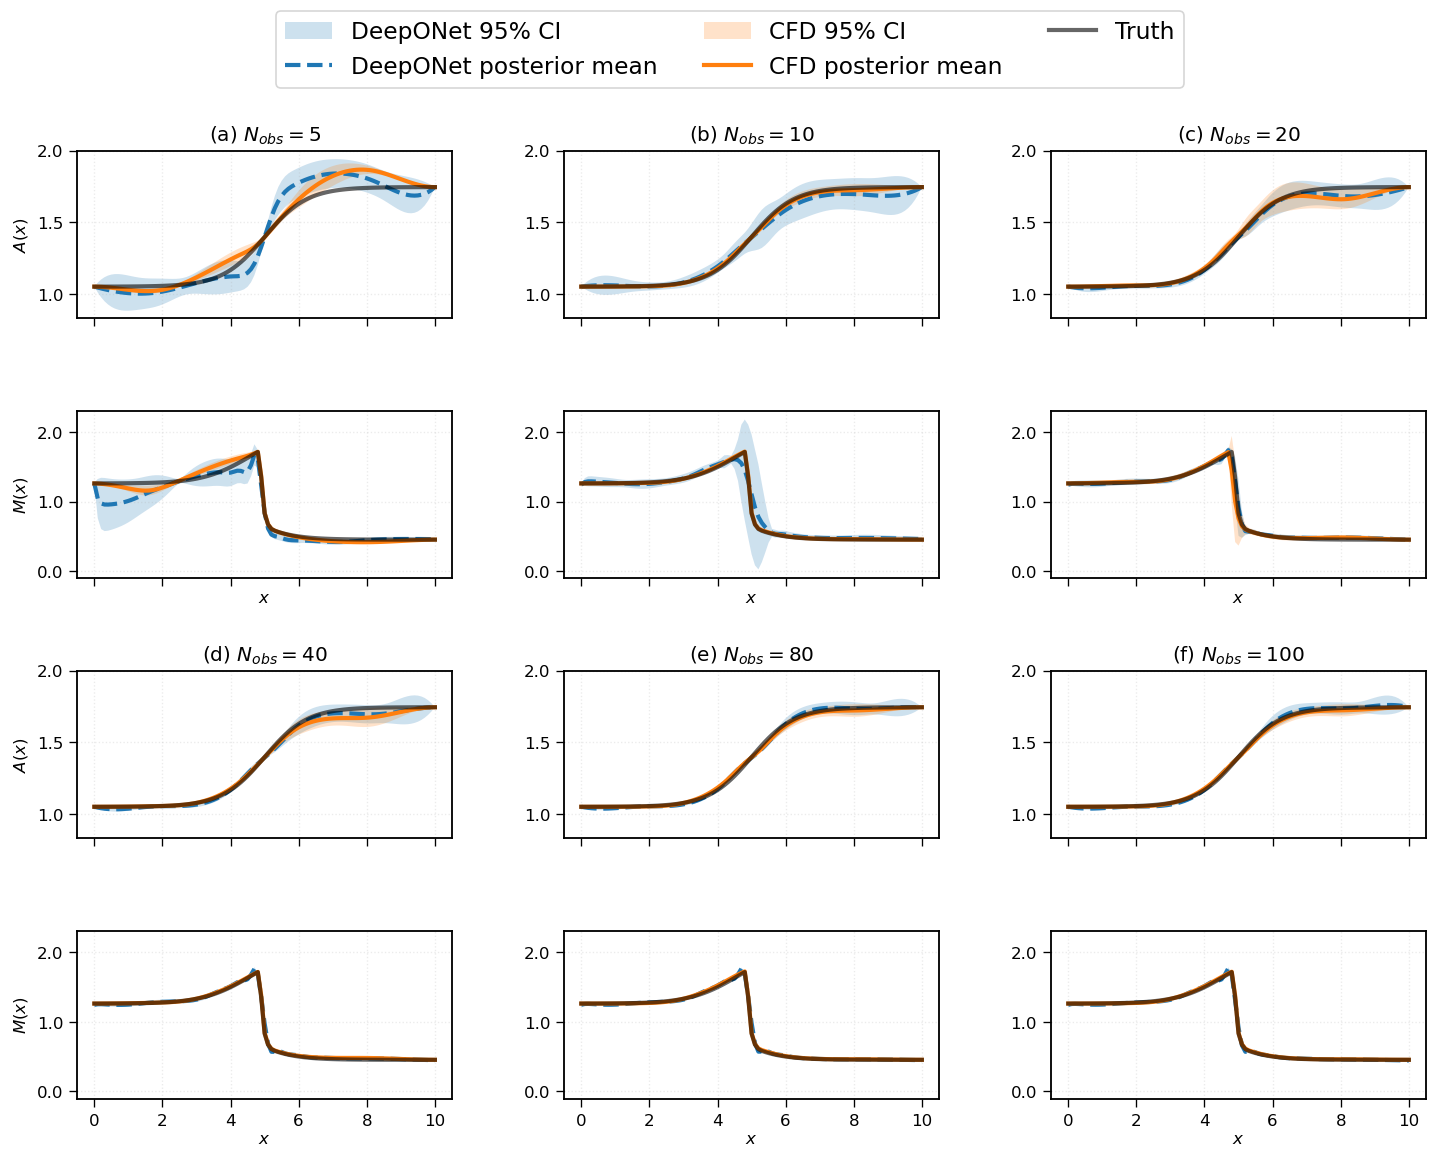

Saved: R5_CFD_vs_DeepONet_top_5_10_20_bottom_40_80_100.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# -----------------------------
# Plot Style
# -----------------------------
plt.rcParams.update({
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "legend.fontsize": 14,   
    "figure.dpi": 120,
    "savefig.dpi": 400,

    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.1,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

# -----------------------------
# File helpers
# -----------------------------
def latest(pattern):
    f = sorted(glob.glob(pattern))
    assert f, f"No files matched: {pattern}"
    return f[-1]

def load_npz(path):
    d = np.load(path, allow_pickle=False)
    return {k: d[k] for k in d.files}

def ensure_bands(d, prefix):
    """
    Ensure {prefix}_lo and {prefix}_hi exist.
    Accepts either:
      - {prefix}_lo/{prefix}_hi
      - {prefix}_mu/{prefix}_sd  -> builds ±2σ band
    """
    mu = d.get(f"{prefix}_mu", None)
    sd = d.get(f"{prefix}_sd", None)
    lo = d.get(f"{prefix}_lo", None)
    hi = d.get(f"{prefix}_hi", None)

    if (lo is None) or (hi is None):
        if (mu is None) or (sd is None):
            raise KeyError(f"Need either {prefix}_lo/{prefix}_hi OR {prefix}_mu/{prefix}_sd in npz.")
        d[f"{prefix}_lo"] = mu - 2.0 * sd
        d[f"{prefix}_hi"] = mu + 2.0 * sd

def extract_sparse_obs(d, Nobs_expected=None):
    """
    Robustly extract (x_obs, M_obs) for plotting.
    """
    x = np.asarray(d["x"])
    N = len(x)

    # obs_idx: prefer saved
    if "obs_idx" in d:
        obs_idx = np.asarray(d["obs_idx"]).astype(np.int32)
    else:
        assert Nobs_expected is not None, "Need Nobs_expected if obs_idx not stored."
        obs_idx = np.linspace(0, N-1, Nobs_expected).round().astype(np.int32)
        obs_idx = np.unique(obs_idx)

    # if x_obs and M_obs are sparse and consistent, use them
    if ("x_obs" in d) and ("M_obs" in d):
        x_obs = np.asarray(d["x_obs"])
        M_obs = np.asarray(d["M_obs"])
        if (len(x_obs) == len(M_obs)) and (len(x_obs) == len(obs_idx)) and (len(x_obs) < N):
            return x_obs, M_obs

    # build full noisy Mach on grid, then subsample
    if "M_obs_full" in d:
        M_full = np.asarray(d["M_obs_full"])
        return x[obs_idx], M_full[obs_idx]

    # sometimes saved as M_obs but it is full length N
    if "M_obs" in d:
        M_candidate = np.asarray(d["M_obs"])
        if len(M_candidate) == N:
            return x[obs_idx], M_candidate[obs_idx]
        if len(M_candidate) == len(obs_idx):
            return x[obs_idx], M_candidate

    # fallback
    return x[obs_idx], np.asarray(d["M_true"])[obs_idx]

def padded_limits(arr_list, pad_frac=0.05):
    a = np.concatenate([np.ravel(np.asarray(v, dtype=np.float64)) for v in arr_list])
    lo, hi = np.min(a), np.max(a)
    pad = pad_frac * (hi - lo + 1e-12)
    return lo - pad, hi + pad

# -----------------------------
# Plotting helper (CFD vs DeepONet)
# -----------------------------
def plot_compare(ax, x, truth,
                 mu_cfd, lo_cfd, hi_cfd,
                 mu_dn,  lo_dn,  hi_dn,
                 title="", ylabel=""):

    # DeepONet band + mean
    h_dn_ci = ax.fill_between(x, lo_dn, hi_dn, alpha=0.22, label="DeepONet 95% CI", zorder=1)
    h_dn_mu, = ax.plot(x, mu_dn, lw=2.5, ls="--", label="DeepONet posterior mean", zorder=3)

    # CFD band + mean
    h_cfd_ci = ax.fill_between(x, lo_cfd, hi_cfd, alpha=0.22, label="CFD 95% CI", zorder=1)
    h_cfd_mu, = ax.plot(x, mu_cfd, lw=2.5, label="CFD posterior mean", zorder=3)

    # Truth
    h_tr, = ax.plot(x, truth, "k", lw=2.5, alpha=0.6, label="Truth", zorder=4)

    if title:
        ax.set_title(title, pad=6)
    ax.set_ylabel(ylabel)
    ax.grid(True)

    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)

    return (h_dn_ci, h_dn_mu, h_cfd_ci, h_cfd_mu, h_tr)

# -----------------------------
# Configuration: TOP (5,10,20) + BOTTOM (40,80,100)
# -----------------------------
NOBS_TOP    = [5, 10, 20]
NOBS_BOTTOM = [40, 80, 100]
NOBS_ALL    = NOBS_TOP + NOBS_BOTTOM


CFD_GLOB = "inverse_nozzle_bspline_{Nobs}*.npz"
DN_FILE  = "inverse_results_DeepONet_{Nobs}obs.npz"

# -----------------------------
# Load data
# -----------------------------
DATA = {}
for Nobs in NOBS_ALL:
    cfd_path = latest(CFD_GLOB.format(Nobs=Nobs))
    dn_path  = DN_FILE.format(Nobs=Nobs)

    cfd = load_npz(cfd_path)
    dn  = load_npz(dn_path)

    ensure_bands(cfd, "A")
    ensure_bands(cfd, "M")
    ensure_bands(dn,  "A")
    ensure_bands(dn,  "M")

    DATA[Nobs] = {"CFD": cfd, "DN": dn, "cfd_path": cfd_path, "dn_path": dn_path}

    print(f"Nobs={Nobs}")
    print("  CFD ->", cfd_path)
    print("  DN  ->", dn_path)

# -----------------------------
# Consistent y-limits
# -----------------------------
A_all, M_all = [], []
for Nobs in NOBS_ALL:
    cfd = DATA[Nobs]["CFD"]
    dn  = DATA[Nobs]["DN"]
    for d in (cfd, dn):
        A_all += [d["A_true"], d["A_mu"], d["A_lo"], d["A_hi"]]
        M_all += [d["M_true"], d["M_mu"], d["M_lo"], d["M_hi"]]

A_ylim = padded_limits(A_all, 0.05)
M_ylim = padded_limits(M_all, 0.06)

# Fixed ticks (as you asked earlier)
A_TICKS = [1.0, 1.5, 2.0]
M_TICKS = [0.0, 1.0, 2.0]
M_TICKLABELS = ["0.0", "1.0", "2.0"]

# Make sure ticks are visible
A_ylim = (min(A_ylim[0], min(A_TICKS)), max(A_ylim[1], max(A_TICKS)))
M_ylim = (min(M_ylim[0], min(M_TICKS)), max(M_ylim[1], max(M_TICKS)))

# -----------------------------
# Figure: 4 × 3
# Rows 0-1 => Nobs = 5,10,20  (A then M)
# Rows 2-3 => Nobs = 40,80,100 (A then M)
# -----------------------------
fig, axes = plt.subplots(
    4, 3,
    figsize=(14.5, 10.0),
    sharex=True,
    gridspec_kw={"wspace": 0.30, "hspace": 0.55}
)

panels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
legend_handles = None

def fill_block(nobs_list, rowA, rowM, panel_offset):
    global legend_handles
    for j, Nobs in enumerate(nobs_list):
        cfd = DATA[Nobs]["CFD"]
        dn  = DATA[Nobs]["DN"]

        x = np.asarray(cfd["x"], dtype=np.float64)

        # --- A(x)
        h = plot_compare(
            axes[rowA, j], x,
            truth=cfd["A_true"],
            mu_dn=dn["A_mu"],   lo_dn=dn["A_lo"],   hi_dn=dn["A_hi"],
            mu_cfd=cfd["A_mu"], lo_cfd=cfd["A_lo"], hi_cfd=cfd["A_hi"],
            title=rf"{panels[panel_offset + j]} $N_{{obs}} = {Nobs}$",
            ylabel=r"$A(x)$" if j == 0 else "",
        )
        axes[rowA, j].set_ylim(*A_ylim)
        axes[rowA, j].set_yticks(A_TICKS)

        # --- M(x)
        _ = plot_compare(
            axes[rowM, j], x,
            truth=cfd["M_true"],
            mu_dn=dn["M_mu"],   lo_dn=dn["M_lo"],   hi_dn=dn["M_hi"],
            mu_cfd=cfd["M_mu"], lo_cfd=cfd["M_lo"], hi_cfd=cfd["M_hi"],
            title="",
            ylabel=r"$M(x)$" if j == 0 else "",
        )
        axes[rowM, j].set_ylim(*M_ylim)
        axes[rowM, j].set_yticks(M_TICKS)
        axes[rowM, j].set_yticklabels(M_TICKLABELS)
        axes[rowM, j].set_xlabel(r"$x$", labelpad=2)

        if legend_handles is None:
            legend_handles = h  # (dn_ci, dn_mean, cfd_ci, cfd_mean, truth)

# Top block: (a)(b)(c)
fill_block(NOBS_TOP, rowA=0, rowM=1, panel_offset=0)
# Bottom block: (d)(e)(f)
fill_block(NOBS_BOTTOM, rowA=2, rowM=3, panel_offset=3)

# -----------------------------
# Shared legend 
# -----------------------------
fig.legend(
    legend_handles,
    ["DeepONet 95% CI", "DeepONet posterior mean", "CFD 95% CI", "CFD posterior mean", "Truth"],
    loc="upper center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02),
    borderaxespad=0.2,
)

fig.subplots_adjust(top=0.90)

out_png = "R5_CFD_vs_DeepONet_top_5_10_20_bottom_40_80_100.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("Saved:", out_png)


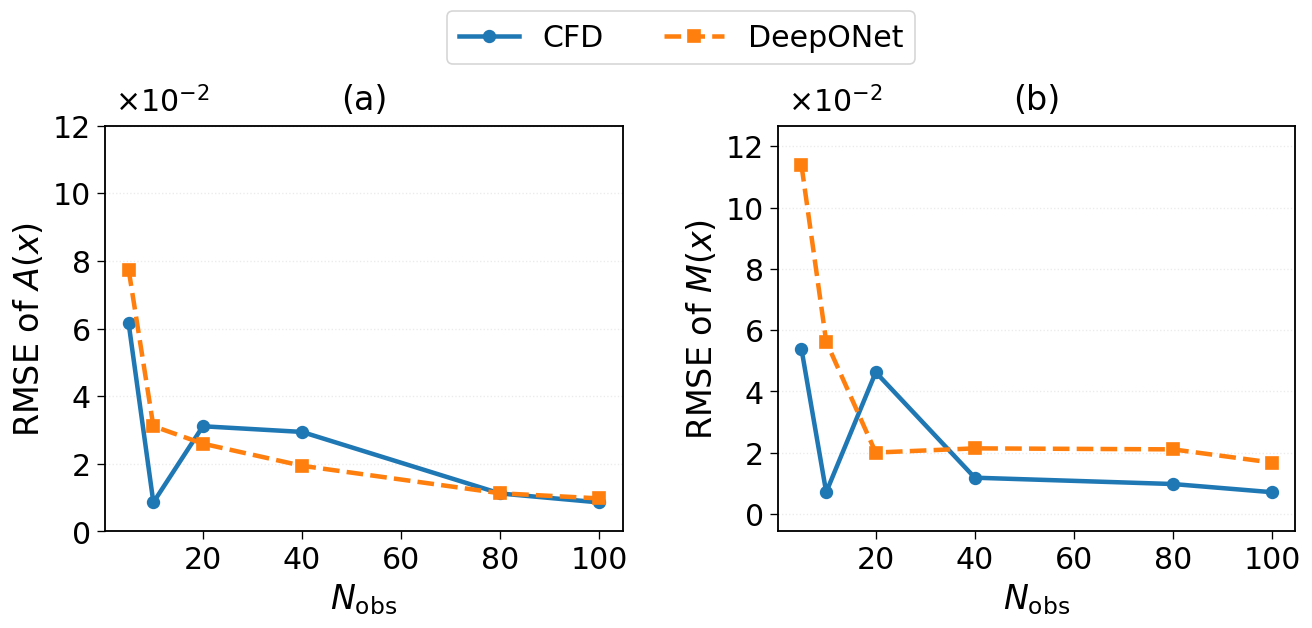

Saved: RMSE_ab_CFD_vs_DeepONet.png RMSE_ab_CFD_vs_DeepONet.pdf


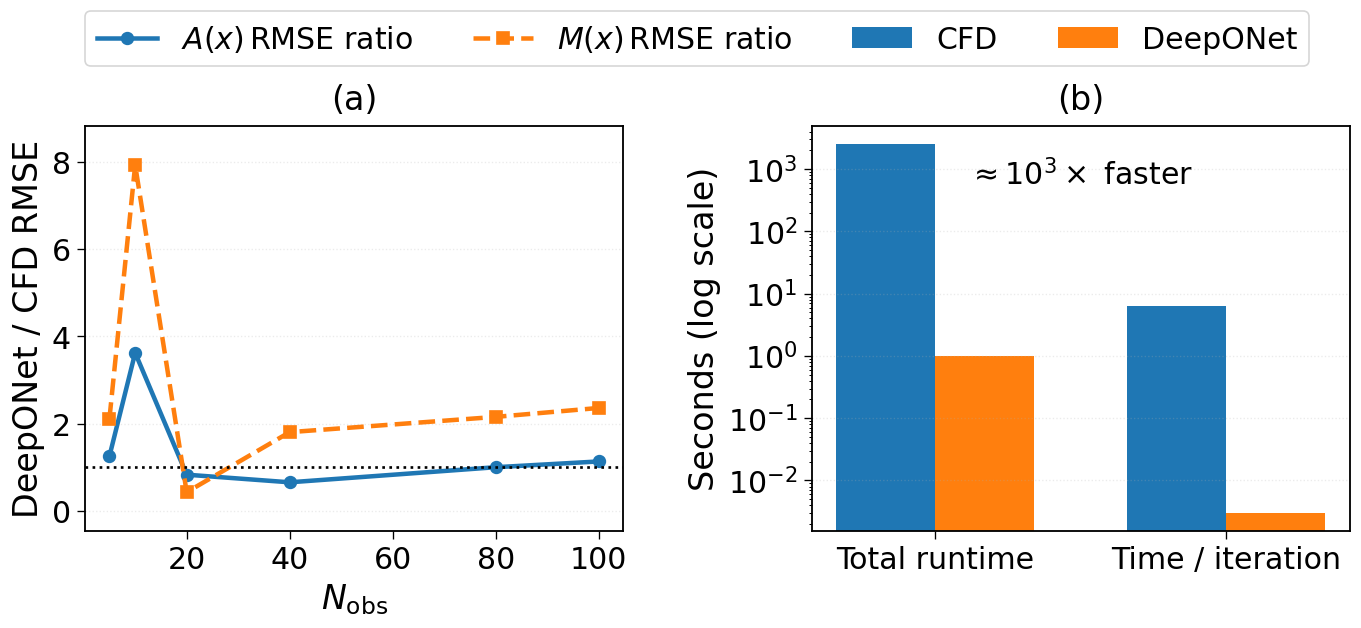

Saved: Ratio_and_Cost_ab.png Ratio_and_Cost_ab.pdf


In [6]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator

# ============================================================
# Global style 
# ============================================================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "legend.fontsize": 18,
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

# ============================================================
# Config
# ============================================================
NOBS_LIST = [5, 10, 20, 40, 80, 100]
CFD_GLOB  = "inverse_nozzle_bspline_{Nobs}*.npz"
DN_FILE   = "inverse_results_DeepONet_{Nobs}obs.npz"

# x-axis ticks 
X_TICKS = [20, 40, 60, 80, 100]

# show RMSE axis as integers with a single ×10^{-2}
MULTIPLIER_POWER = -2
MAJOR_LABELS     = np.array([0, 2, 4, 6, 8, 10 , 12], dtype=float)   


# ============================================================
# Helpers
# ============================================================
def latest(pattern: str) -> str:
    files = sorted(glob.glob(pattern))
    assert files, f"No files matched: {pattern}"
    return files[-1]

def load_npz(path: str) -> dict:
    d = np.load(path, allow_pickle=False)
    return {k: d[k] for k in d.files}

def rmse(a, b) -> float:
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def pad_limits(values, pad=0.12):
    v = np.asarray(values, dtype=np.float64)
    v = v[np.isfinite(v)]
    lo, hi = float(v.min()), float(v.max())
    span = hi - lo + 1e-12
    return lo - pad * span, hi + pad * span

def format_linear_axis_with_multiplier(ax, ymin, ymax, multiplier_power=-2, major_labels=None):
    """
    LINEAR axis with fixed major ticks displayed as `major_labels`,
    but actual tick positions are `major_labels * 10^(multiplier_power)`.
    Adds a single ×10^{multiplier_power} label at top-left.
    """
    if major_labels is None:
        major_labels = np.array([0, 2, 4, 6, 8], dtype=float)

    scale = 10.0 ** multiplier_power
    major_ticks = major_labels * scale

    ax.set_yscale("linear")
    ax.set_ylim(ymin, ymax)

    ax.yaxis.get_offset_text().set_visible(False)
    ax.yaxis.set_minor_locator(NullLocator())

    # keep only ticks inside ylim
    mask = (major_ticks >= ymin) & (major_ticks <= ymax)
    major_ticks  = major_ticks[mask]
    major_labels = major_labels[mask]

    ax.yaxis.set_major_locator(FixedLocator(major_ticks))

    def _fmt(y, _):
        for t, lbl in zip(major_ticks, major_labels):
            if np.isclose(y, t, rtol=0.0, atol=1e-14):
                return f"{int(lbl)}" if np.isclose(lbl, round(lbl)) else f"{lbl:g}"
        return ""

    ax.yaxis.set_major_formatter(FuncFormatter(_fmt))

    # multiplier label 
    ax.text(
        0.02, 1.02, rf"$\times 10^{{{multiplier_power}}}$",
        transform=ax.transAxes, ha="left", va="bottom"
    )

    ax.grid(True, which="major", axis="y")

def box_spines(ax):
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)

# ============================================================
# Load + compute RMSEs
# ============================================================
rmse_A_cfd, rmse_A_dn = [], []
rmse_M_cfd, rmse_M_dn = [], []

for Nobs in NOBS_LIST:
    cfd_path = latest(CFD_GLOB.format(Nobs=Nobs))
    dn_path  = DN_FILE.format(Nobs=Nobs)
    assert os.path.exists(dn_path), f"Missing DeepONet file: {dn_path}"

    cfd = load_npz(cfd_path)
    dn  = load_npz(dn_path)

    A_true = cfd["A_true"]
    M_true = cfd["M_true"]

    rmse_A_cfd.append(rmse(cfd["A_mu"], A_true))
    rmse_A_dn.append(rmse(dn["A_mu"],  A_true))

    rmse_M_cfd.append(rmse(cfd["M_mu"], M_true))
    rmse_M_dn.append(rmse(dn["M_mu"],  M_true))

xN = np.asarray(NOBS_LIST, dtype=np.int32)
rmse_A_cfd = np.asarray(rmse_A_cfd, dtype=np.float64)
rmse_A_dn  = np.asarray(rmse_A_dn,  dtype=np.float64)
rmse_M_cfd = np.asarray(rmse_M_cfd, dtype=np.float64)
rmse_M_dn  = np.asarray(rmse_M_dn,  dtype=np.float64)

ratio_A = rmse_A_dn / rmse_A_cfd
ratio_M = rmse_M_dn / rmse_M_cfd

# limits 
scale = 10.0 ** MULTIPLIER_POWER
major_ticks = MAJOR_LABELS * scale

A_ylim = pad_limits(np.r_[rmse_A_cfd, rmse_A_dn], pad=0.12)
M_ylim = pad_limits(np.r_[rmse_M_cfd, rmse_M_dn], pad=0.12)

A_ylim = (min(A_ylim[0], major_ticks.min()), max(A_ylim[1], major_ticks.max()))
M_ylim = (min(M_ylim[0], major_ticks.min()), max(M_ylim[1], major_ticks.max()))

# ============================================================
# FIGURE 1: RMSE (a) and (b)
# ============================================================
fig1, ax1 = plt.subplots(1, 2, figsize=(12.8, 4.9), gridspec_kw={"wspace": 0.30})

# (a) Geometry RMSE
ax1[0].plot(xN, rmse_A_cfd, "o-",  lw=2.7, ms=7, label="CFD")
ax1[0].plot(xN, rmse_A_dn,  "s--", lw=2.7, ms=7, label="DeepONet")
format_linear_axis_with_multiplier(
    ax1[0], A_ylim[0], A_ylim[1],
    multiplier_power=MULTIPLIER_POWER,
    major_labels=MAJOR_LABELS
)
ax1[0].set_xlabel(r"$N_{\mathrm{obs}}$")
ax1[0].set_ylabel(r"RMSE of $A(x)$")
ax1[0].set_title(r"(a)", pad=10)
ax1[0].set_xticks(X_TICKS)
box_spines(ax1[0])

# (b) Mach RMSE
ax1[1].plot(xN, rmse_M_cfd, "o-",  lw=2.7, ms=7, label="CFD")
ax1[1].plot(xN, rmse_M_dn,  "s--", lw=2.7, ms=7, label="DeepONet")
format_linear_axis_with_multiplier(
    ax1[1], M_ylim[0], M_ylim[1],
    multiplier_power=MULTIPLIER_POWER,
    major_labels=MAJOR_LABELS
)
ax1[1].set_xlabel(r"$N_{\mathrm{obs}}$")
ax1[1].set_ylabel(r"RMSE of $M(x)$")
ax1[1].set_title(r"(b)", pad=10)
ax1[1].set_xticks(X_TICKS)
box_spines(ax1[1])

# legend 
h, l = ax1[0].get_legend_handles_labels()
fig1.legend(h, l, loc="upper center", ncol=2, frameon=True, bbox_to_anchor=(0.5, 1.02))
fig1.subplots_adjust(top=0.80)

out_png1 = "RMSE_ab_CFD_vs_DeepONet.png"
out_pdf1 = "RMSE_ab_CFD_vs_DeepONet.pdf"
plt.savefig(out_png1, dpi=300, bbox_inches="tight")
# plt.savefig(out_pdf1, bbox_inches="tight")
plt.show()
print("Saved:", out_png1, out_pdf1)

# ============================================================
# FIGURE 2: Ratio (a) + Cost (b) showing ~10^3 faster
# ============================================================
fig2, ax2 = plt.subplots(1, 2, figsize=(13.6, 4.9), gridspec_kw={"wspace": 0.35})

# (a) Relative error ratio
R_lo = min(np.min(ratio_A), np.min(ratio_M), 1.0)
R_hi = max(np.max(ratio_A), np.max(ratio_M), 1.0)
R_pad = 0.12 * (R_hi - R_lo + 1e-12)
ax2[0].set_ylim(R_lo - R_pad, R_hi + R_pad)

ax2[0].plot(xN, ratio_A, "o-",  lw=2.7, ms=7, label=r"$A(x)\,\text{RMSE ratio}$")
ax2[0].plot(xN, ratio_M, "s--", lw=2.7, ms=7, label=r"$M(x)\,\text{RMSE ratio}$")
ax2[0].axhline(1.0, color="k", lw=1.6, ls=":")
ax2[0].set_xlabel(r"$N_{\mathrm{obs}}$")
ax2[0].set_ylabel(r"DeepONet / CFD RMSE")
ax2[0].set_title(r"(a)", pad=10)
ax2[0].grid(True, axis="y")
ax2[0].set_xticks(X_TICKS)
box_spines(ax2[0])

# (b) Cost (log)
# Table values (seconds):
cfd_total_s = 42.0 * 60.0   # ~42 min
dn_total_s  = 1.0          
cfd_it_s    = 6.4
dn_it_s     = 0.003

groups = ["Total runtime", "Time / iteration"]
xg = np.arange(len(groups))
w = 0.34

ax2[1].bar(xg - w/2, [cfd_total_s, cfd_it_s], width=w, label="CFD")
ax2[1].bar(xg + w/2, [dn_total_s,  dn_it_s ], width=w, label="DeepONet")

ax2[1].set_yscale("log")
ax2[1].set_xticks(xg)
ax2[1].set_xticklabels(groups)
ax2[1].set_ylabel("Seconds (log scale)")
ax2[1].set_title(r"(b)", pad=10)
ax2[1].grid(True, which="major", axis="y")
box_spines(ax2[1])

# annotation: "≈ 10^3× faster" 
ax2[1].text(
    0.5, 0.92, r"$\approx 10^{3}\times$ faster",
    transform=ax2[1].transAxes, ha="center", va="top"
)

# shared legend above 
h0, l0 = ax2[0].get_legend_handles_labels()
h1, l1 = ax2[1].get_legend_handles_labels()
fig2.legend(h0 + h1, l0 + l1, loc="upper center", ncol=4, frameon=True, bbox_to_anchor=(0.5, 1.02))
fig2.subplots_adjust(top=0.80)

out_png2 = "Ratio_and_Cost_ab.png"
out_pdf2 = "Ratio_and_Cost_ab.pdf"
plt.savefig(out_png2, dpi=300, bbox_inches="tight")
# plt.savefig(out_pdf2, bbox_inches="tight")
plt.show()
print("Saved:", out_png2, out_pdf2)
